In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## Analysing Entgeltatlas data

In [2]:
df_entgeltatlas_2 = pd.read_csv('../data_1/raw_data/entgeltatlas_complete_data.csv')

In [3]:
df_entgeltatlas_2.head(5)

,kldb,entgelt,entgeltQ25,entgeltQ75,besetzung,region.id,region.bezeichnung,region.schluessel,region.oberRegionId,region.oberRegionBezeichnung,region.beitragsBemessungsGrenze,gender.id,gender.bezeichnung,ageCategory.id,ageCategory.bezeichnung,performanceLevel.id,performanceLevel.bezeichnung,branche.id,branche.bezeichnung
0,93532,3386,2778,4042,641,1,Deutschland,D,NaN,NaN,7450,1,Gesamt,1,Gesamt,2,Fachkraft,1,Gesamt
1,93532,3417,2808,4126,594,1,Deutschland,D,NaN,NaN,7450,1,Gesamt,1,Gesamt,2,Fachkraft,3,produzierendes Gewerbe ohne Bau
2,93532,3509,2869,4251,500,1,Deutschland,D,NaN,NaN,7450,2,Männer,1,Gesamt,2,Fachkraft,1,Gesamt
3,93532,3433,2814,4163,582,3,Westdeutschland,W,1.0,Deutschland,7550,1,Gesamt,1,Gesamt,2,Fachkraft,1,Gesamt
4,93532,3486,2854,4219,546,3,Westdeutschland,W,1.0,Deutschland,7550,1,Gesamt,1,Gesamt,2,Fachkraft,3,produzierendes Gewerbe ohne Bau


In [4]:
df_entgeltatlas_2.columns

Index(['kldb', 'entgelt', 'entgeltQ25', 'entgeltQ75', 'besetzung', 'region.id',
       'region.bezeichnung', 'region.schluessel', 'region.oberRegionId',
       'region.oberRegionBezeichnung', 'region.beitragsBemessungsGrenze',
       'gender.id', 'gender.bezeichnung', 'ageCategory.id',
       'ageCategory.bezeichnung', 'performanceLevel.id',
       'performanceLevel.bezeichnung', 'branche.id', 'branche.bezeichnung'],
      dtype='object')

In [5]:
df_standard_kldb = pd.read_excel('../input/kldb_berufsbenennungen.xlsx')

## Standard kldb codes with occupation titles

In [6]:
df_standard_kldb.head()


,Berufsbenennungen,KldB-2010_(5-Steller)
0,3-D-Artist,23224
1,3-D-Designer/in,23223
2,3-D-Druck-Spezialist/in,27103
3,Abbrucharbeiter/in,32101
4,Abdichter/in (Dachdeckerei),33232


In [7]:
avg_salary_kldb = df_entgeltatlas_2.groupby("kldb")["entgelt"].mean().reset_index()

In [8]:
avg_salary_kldb

,kldb,entgelt
0,111,3283.830409
1,112,2794.559140
2,113,2455.710526
3,114,2948.800000
4,115,2955.350000
...,...,...
1076,94623,4004.833333
1077,94704,4789.750000
1078,94712,4285.500000
1079,94713,4247.000000


In [9]:
avg_salary_kldb = avg_salary_kldb[avg_salary_kldb['kldb']>9999]

In [10]:
avg_salary_kldb = avg_salary_kldb.sort_values(by="entgelt", ascending=False)

In [11]:
avg_salary_kldb

,kldb,entgelt
807,72184,7454.687500
649,52314,7453.500000
543,41394,7447.333333
890,81454,7437.818182
648,52313,7405.500000
...,...,...
643,52112,2312.162500
932,82322,2289.808511
931,82312,2112.856061
930,82311,1993.083333


In [12]:
avg_salary_kldb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 941 entries, 807 to 764
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   kldb     941 non-null    int64  
 1   entgelt  941 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 22.1 KB


In [13]:
avg_salary_kldb["kldb"] = avg_salary_kldb["kldb"].astype(str)

In [14]:
avg_salary_kldb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 941 entries, 807 to 764
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   kldb     941 non-null    object 
 1   entgelt  941 non-null    float64
dtypes: float64(1), object(1)
memory usage: 22.1+ KB


### Ploting salaries of top 10 occupations

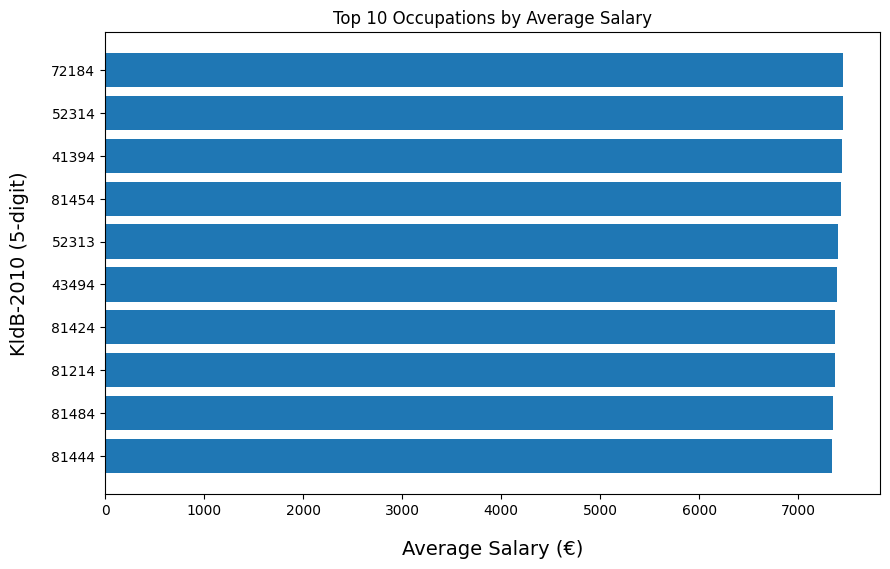

In [15]:
top10 = avg_salary_kldb.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["kldb"], top10["entgelt"])

plt.title("Top 10 Occupations by Average Salary")
plt.xlabel("Average Salary (€)", fontsize=14, labelpad=16)
plt.ylabel("KldB-2010 (5-digit)", fontsize=14, labelpad=16)

plt.gca().invert_yaxis()
plt.savefig("../pictures/avg_salary_kldb.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
avg_salary_location = df_entgeltatlas_2.groupby("region.bezeichnung")["entgelt"].mean().reset_index()

In [17]:
avg_salary_location = avg_salary_location.sort_values(by="entgelt", ascending=False)

In [18]:
avg_salary_location.head()

,region.bezeichnung,entgelt
27,Stuttgart,5211.855309
17,München,5091.990651
10,Frankfurt am Main,5016.892872
8,Düsseldorf,4846.960533
11,Hamburg,4754.436165


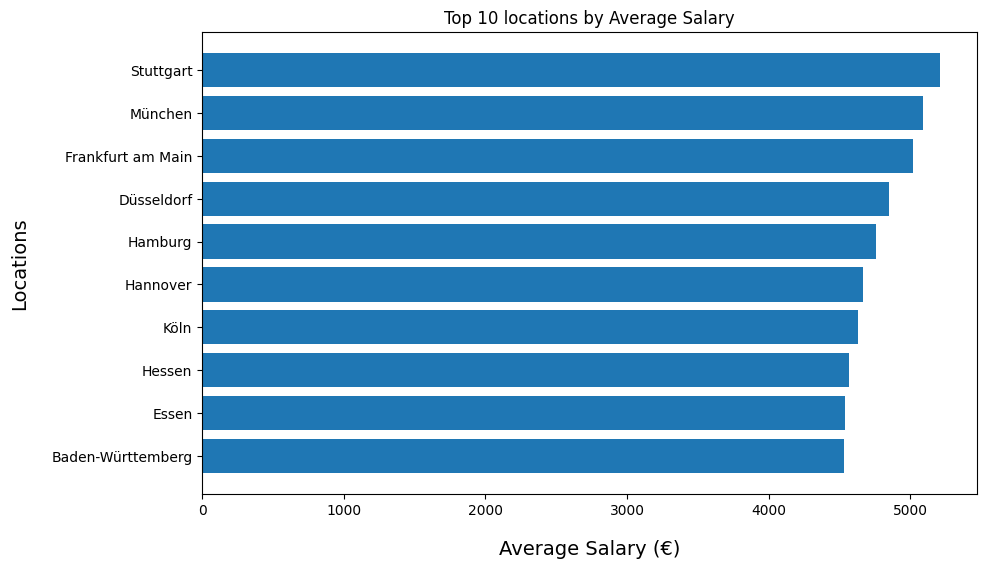

In [19]:
top10_locations = avg_salary_location.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10_locations["region.bezeichnung"], top10_locations["entgelt"])

plt.title("Top 10 locations by Average Salary")
plt.xlabel("Average Salary (€)", fontsize=14, labelpad=16)
plt.ylabel("Locations", fontsize=14, labelpad=16)

plt.gca().invert_yaxis()
plt.savefig("../pictures/avg_salary_location.png", dpi=300, bbox_inches="tight")
plt.show()